In [25]:
import sys
sys.path.append("..")
%run "../moduli.py"

Funzione Teorica
$$A(\omega) = \frac{1}{\sqrt{ (1 - \frac{\omega^2}{\Omega^2})^2 + \frac{1}{Q^2}\frac{\omega^2}{\Omega^2}}}$$

con $ \omega = 2 \pi f$.

In [26]:
def modello(par, f):  # f in Hz
    Omega, Q, area, x_off, y_off = par
    omega = 2 * np.pi * (f + x_off)
    #omega = f + x_off
    return area / np.sqrt(
        (1 - (omega**2 / Omega**2))**2 +
        (1 / Q**2) * (omega**2 / Omega**2)
    ) + y_off

param_labels = ["\\omega_0", "Q", "A", "f_{off}", "A_{off}"]

beta0 = [2*np.pi*70000, 6, 1, 1, 1]

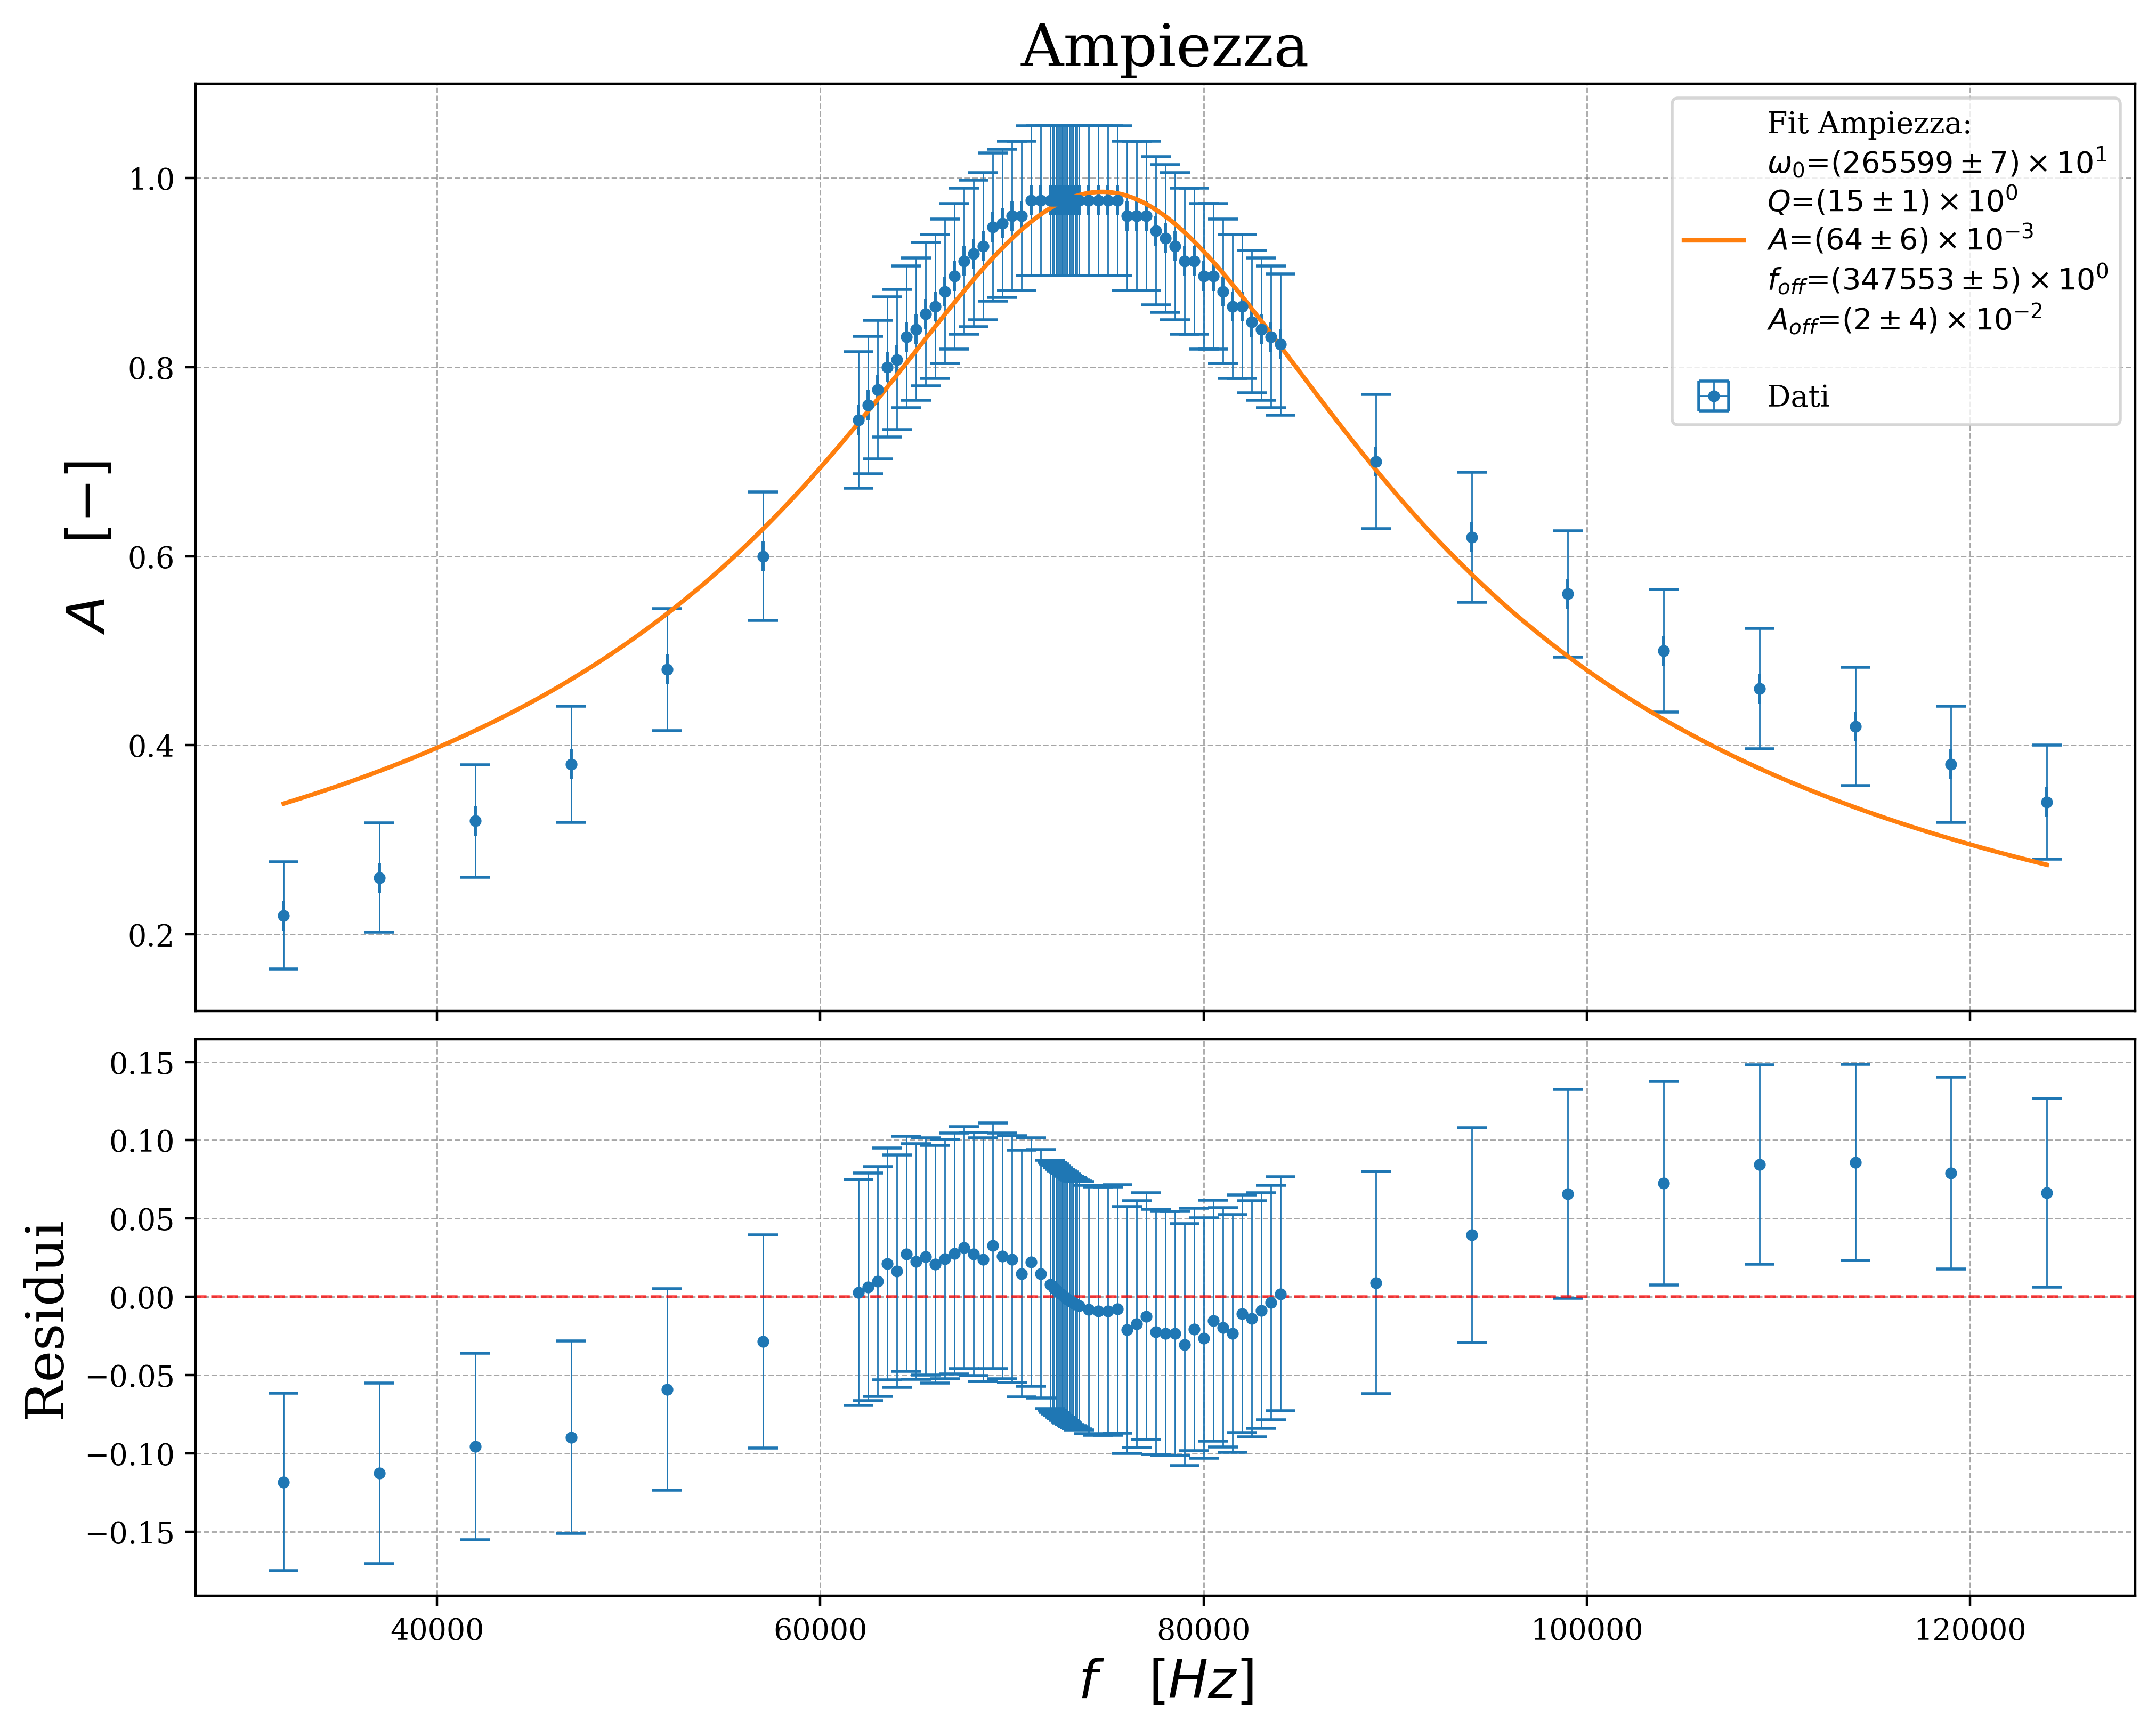

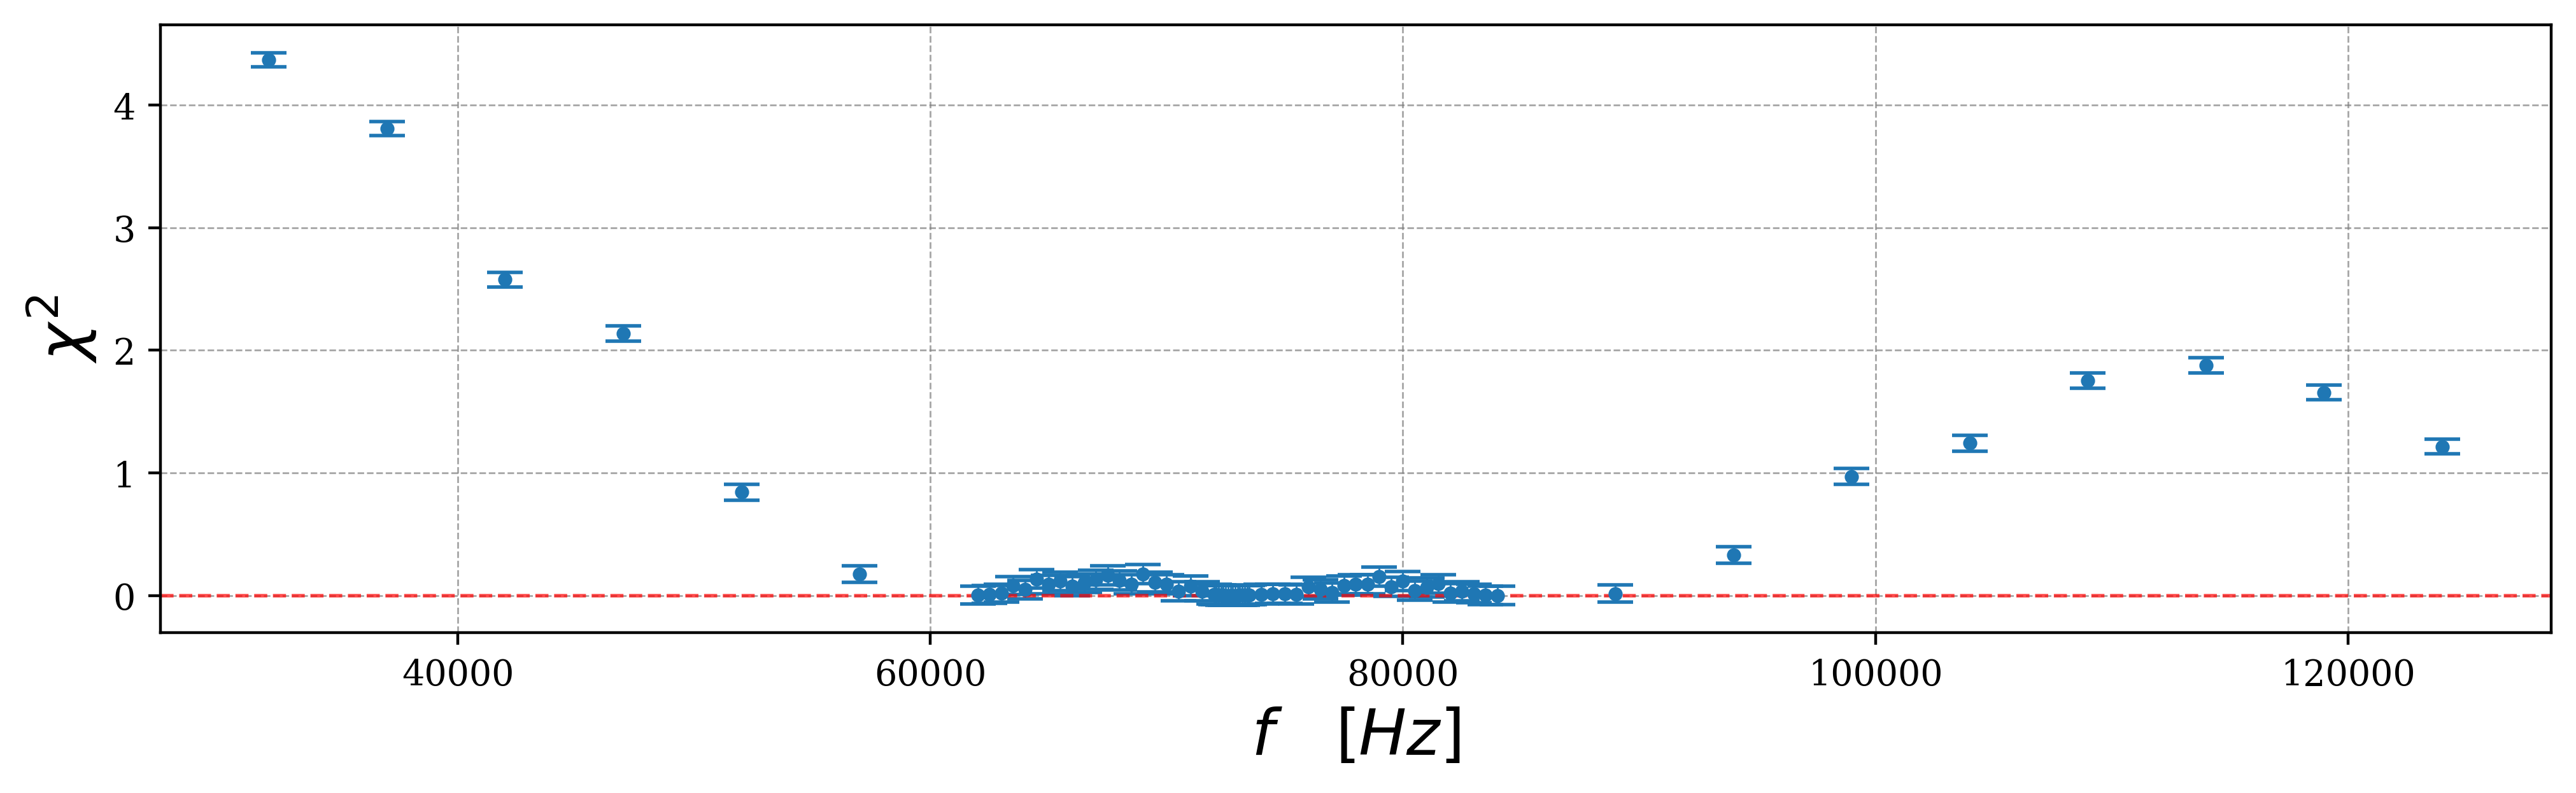

In [27]:
analisi = analizza("ampiezza", modello, param_labels, beta0, legenda_fontsize = 10)

In [28]:
print(analisi)

Parametri regressione :
2655989.8650086666 ± 69.93747554797599
15.095285694323154 ± 1.017459306595793
0.06361303792765971 ± 0.0063929835734473145
347552.7108098405 ± 5.410968963405624
0.024510503078086835 ± 0.03859561079110682

Somma residui :
0.0979
Somma chi quadri e chi ridotto :
25.8046
0.3910



In [29]:
par = analisi.anal[0]
spar = analisi.anal[1]

parametri_profilazione = [[par[0], par[1], par[2]], [spar[0], spar[1], spar[2]]]
parametri_offset = [par[3], par[4]]
parametri = [parametri_profilazione, parametri_offset]
let.esporta_pickle(parametri, "ampiezza.pkl")